In [1]:
import os
os.environ.pop("LD_LIBRARY_PATH", None)
os.environ["PATH"] = "/usr/bin:/bin:" + os.environ["PATH"]

In [2]:
import math
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from classy import Class
from matplotlib.ticker import LogLocator, NullFormatter, MultipleLocator, AutoMinorLocator
import matplotlib.patheffects as pe

In [3]:
flag_save_plot = False

## SETUP: LCDM and LCDM + Monopoles

In [4]:
# =======================
# CONFIG / GRID
# =======================
a_grid = np.logspace(-7, 0, 900)

# =======================
# BASE COSMOLOGY: Planck 2018 TT,TE,EE+lowE
# =======================
h_fixed     = 0.6727
theta_s_100 = 1.04090
omega_b     = 0.02236
omega_cdm0  = 0.1202
tau_reio    = 0.0544
A_s         = np.exp(3.045) * 1e-10
n_s         = 0.9649

base_params = {
    # "theta_s_100": theta_s_100,
    "h": h_fixed,
    "omega_b": omega_b,
    "omega_cdm": omega_cdm0,
    "A_s": A_s,
    "n_s": n_s,
    "tau_reio": tau_reio,

    # we only need background; output can be minimal
    # (still keep tCl if you want consistency with previous runs)
    "output": "tCl,lCl",
    "lensing": "yes",
    "l_max_scalars": 2500,
    "headers": "yes",
    "format": "camb",   # optional, gives μK^2-style outputs

    # precision overrides
    # 'tol_background_integration': 1e-8,
    # 'background_integration_stepsize': 0.001,
    # 'background_Nloga': 2000000
    'background_Nloga': 2000000

}

# =======================
# PARAM BUILDERS
# =======================
def params_reference():
    p = dict(base_params)
    return p

def params_monopoles(f_mon, kappa_mon, a_t_mon):
    p = dict(base_params)
    p["f_mon"] = float(f_mon)
    p["kappa_mon"] = float(kappa_mon)
    p["a_t_mon"] = float(a_t_mon)
    return p

In [5]:
# =======================
# CLASSY RUNNER
# =======================
def compute_background_arrays_base(pars):
    """
    Returns:
      a_arr, H_arr (in 1/Mpc), plus optional rho arrays if present in background dict.
    """
    cosmo = Class()
    cosmo.set(pars)
    cosmo.compute()

    bg = cosmo.get_background()  # dict of numpy arrays
    # bg keys typically include: 'z', 'H [1/Mpc]', '(.)rho_cdm', '(.)rho_dcdm', '(.)rho_dr', ...
    z = bg["z"]
    a = 1.0/(1.0+z)

    # H key name can differ slightly across versions; try common ones:
    if "H [1/Mpc]" in bg:
        H = bg["H [1/Mpc]"]
    elif "H" in bg:
        H = bg["H"]
    else:
        raise KeyError(f"Could not find H in background keys: {list(bg.keys())[:50]}")

    rho_cdm  = bg.get("(.)rho_cdm", None)

    cosmo.struct_cleanup()
    cosmo.empty()
    return a, H, rho_cdm

def compute_background_arrays(pars):
    """
    Returns:
      a_arr, H_arr (in 1/Mpc), plus optional rho arrays if present in background dict.
    """
    cosmo = Class()
    cosmo.set(pars)
    cosmo.compute()

    bg = cosmo.get_background()  # dict of numpy arrays
    # bg keys typically include: 'z', 'H [1/Mpc]', '(.)rho_cdm', '(.)rho_dcdm', '(.)rho_dr', ...
    z = bg["z"]
    a = 1.0/(1.0+z)

    # H key name can differ slightly across versions; try common ones:
    if "H [1/Mpc]" in bg:
        H = bg["H [1/Mpc]"]
    elif "H" in bg:
        H = bg["H"]
    else:
        raise KeyError(f"Could not find H in background keys: {list(bg.keys())[:50]}")

    rho_dcdm = bg.get("(.)rho_mon", None)
    rho_dr   = bg.get("(.)rho_dr", None)
    rho_cdm  = bg.get("(.)rho_cdm", None)

    cosmo.struct_cleanup()
    cosmo.empty()
    return a, z, H, rho_cdm, rho_dcdm, rho_dr

def interp_on_log_a(a_src, y_src, a_tgt):
    x_src = np.log(a_src)
    x_tgt = np.log(a_tgt)
    order = np.argsort(x_src)
    return np.interp(x_tgt, x_src[order], y_src[order])

In [6]:
# =======================
# REFERENCE H(a)
# =======================
a_ref, H_ref, rho_cdm_ref = compute_background_arrays_base(params_reference())
H_ref_on = interp_on_log_a(a_ref, H_ref, a_grid)

## CDM + monopoles density profile

In [7]:
def smart_format(x):
    if abs(x) < 100:
        return f"{x:.1f}"
    else:
        return f"{x:.0f}"

def plot_evolution_comoving_dm_density(
    f_mon,
    kappa_mon_arr,
    a_t_mon_arr,
    *,
    rho0=None,
    title=None,
    xlim=(0.0, 20.0),
    ylim=(-0.05, 1.05),
    legend_loc="lower right",
    savepath=None,
    return_fig=False,
    style_map=None,
    show=True,
):
    """
    Plot the evolution of the *total comoving DM density* in the monopole-decay model:
        y(a) = a^3 [rho_cdm(a) + rho_dcdm(a)] / rho_cdm^0

    where:
      - rho_cdm is the stable CDM density
      - rho_dcdm is the decaying (monopole) CDM-like component
      - rho_cdm^0 is today's stable CDM density used for normalization

    Parameters
    ----------
    Gamma0_arr : array-like of float
        List/array of Γ0 values to scan over.
        Interpretation depends on your CLASS implementation:
          - If you pass `Gamma0_mon` and CLASS uses it directly (in 1/Mpc), then Γ0 sets the decay scale.
          - If CLASS rescales internally, Γ0 is a dimensionless knob controlling the effective decay.

    Dlna_arr : array-like of float
        List/array of Δln a values controlling the *width* of the transition
        in your tanh gate:
            turn_on = 0.5 * (1 + tanh((ln a - ln a_t)/Δln a))
        Smaller Δln a → sharper turn-on.

    f_mon : float
        Excess fraction of CDM in the early universe (your convention):
            Omega_ini_dcdm = f_mon * Omega0_cdm
        So early-time comoving DM is (1 + f_mon) times the stable CDM,
        before conversion to DR.

    z_t : float
        Transition redshift defining the midpoint a_t = 1/(1+z_t)
        of the tanh gate.

    Keyword-only options
    --------------------
    rho0 : float, optional
        Normalization ρ_cdm^0. If None, uses global `rho_cdm_ref[-1]`.
        (Assumes you computed a ΛCDM reference background already.)

    title : str, optional
        Custom plot title. If None, a default title with a_t and f_mon is used.

    xlim, ylim : tuple
        Axis limits.

    legend_loc : str
        Matplotlib legend location.

    savepath : str, optional
        If provided, saves the figure to this path.

    return_fig : bool
        If True, returns (fig, ax) instead of only showing.

    style_map : dict, optional
        Map Δln a -> style dict, e.g. {0.2: dict(lw=2.4, ls='-')}
        If None, a reasonable default is used.

    Notes
    -----
    Requires the helper functions already defined in your notebook:
      - params_monopoles(f_mon, z_t, Dlna, Gamma0)
      - compute_background_arrays(params) -> (a, H, rho_cdm, rho_dcdm, rho_dr)
    and a reference array:
      - rho_cdm_ref (from a ΛCDM run), used to get rho_cdm_ref[-1].
    """

    # ---- normalize + validate inputs ----
    kappa_mon_arr = np.atleast_1d(kappa_mon_arr).astype(float)
    a_t_mon_arr  = np.atleast_1d(a_t_mon_arr).astype(float)

    if np.any(kappa_mon_arr <= 0):
        raise ValueError("All kappa_mon values must be > 0.")
    if np.any(a_t_mon_arr <= 0):
        raise ValueError("All a_t_mon a values must be > 0.")
    if not (f_mon >= 0):
        raise ValueError("f_mon must be >= 0.")

    # Reference stable-CDM comoving normalization
    if rho0 is None:
        try:
            rho0 = rho_cdm_ref[-1]
        except NameError:
            raise NameError("rho0 not provided and global rho_cdm_ref is not defined.")

    # ---- default style map ----
    if style_map is None:
        style_map = {
            0.05: dict(lw=2.6, ls='-'),
            0.10: dict(lw=2.6, ls='-'),
            0.20: dict(lw=2.6, ls='-'),
            0.40: dict(lw=2.6, ls='-'),
            0.80: dict(lw=2.6, ls='-'),
        }

    # ---- figure/axes ----
    fig, ax = plt.subplots(figsize=(7.2, 4.8))

    # ---- main loop ----
    for i in range(len(kappa_mon_arr)):
        kappa = kappa_mon_arr[i]
        a_t_mon = a_t_mon_arr[i]

        pars = params_monopoles(f_mon, kappa, a_t_mon)
        a_m, z_m, H_m, rho_cdm, rho_dcdm, rho_dr = compute_background_arrays(pars)

        if rho_dcdm is None or rho_cdm is None:
            raise RuntimeError(
                "Missing rho_cdm or rho_dcdm in background output. "
                "Check that your CLASS output includes '(.)rho_cdm' and '(.)rho_dcdm'."
            )

        # total comoving DM (stable + monopole)
        # comov_tot = a_m**3 * (rho_cdm + rho_dcdm)
        comov_tot = a_m**3 * (rho_dcdm)
        y = comov_tot / (rho0*f_mon)

        mantissa_at, exponent_at = f"{a_t_mon:.2e}".split('e')
        lab = rf"$\kappa={smart_format(kappa)}$, $a_t={mantissa_at} \cdot 10^{{{int(exponent_at)}}}$"
        ax.plot(z_m, y, label=lab, **style_map.get(float(a_t_mon), dict(lw=2.5)))

    # ---- axes styling ----
    # ax.set_xscale("log")
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)

    ax.set_xlabel(r"$z$", fontsize=13)
    ax.set_ylabel(r"$a^3\,\rho_{\rm mon}(a)/\rho_{\rm mon}^0$", fontsize=13)
    # ax.xaxis.set_major_locator(LogLocator(base=10.0, numticks=9))
    # ax.xaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(2, 10)*0.1, numticks=100))
    # ax.xaxis.set_minor_formatter(NullFormatter())

    ax.yaxis.set_major_locator(MultipleLocator(0.2))
    ax.yaxis.set_minor_locator(AutoMinorLocator(2))

    ax.tick_params(axis='both', which='major', direction='in', top=True, right=True,
                   length=6, width=1.0, labelsize=11)
    ax.tick_params(axis='both', which='minor', direction='in', top=True, right=True,
                   length=3, width=0.8)

    ax.legend(frameon=False, fontsize=10, loc=legend_loc, ncol=1)

    if title is None:
        title = rf"$f_{{\rm mon}}={f_mon}$"
    ax.set_title(title, fontsize=13, pad=10)

    fig.tight_layout()

    if savepath is not None:
        fig.savefig(savepath, dpi=200, bbox_inches="tight")

    if show:
        plt.show()
        
    if return_fig:
        return fig, ax

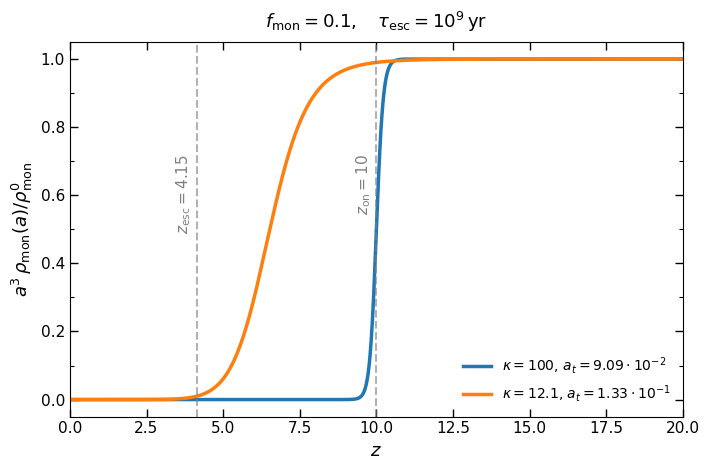

In [8]:
# =======================
# Plot settings
# =======================
f_mon = 0.1
kappa_mon_arr = [100, 12.0980]
a_t_mon_arr = [1/(10+1), 0.132912]

tau_escape = 10**(9)
mantissa, exponent = f"{tau_escape:.1e}".split('e')



z_on = 10.0
z_escape = 4.1461

# Make plot but DON'T show yet
fig, ax = plot_evolution_comoving_dm_density(
    f_mon, kappa_mon_arr, a_t_mon_arr,
    title = rf"$f_{{\rm mon}}={f_mon}, \quad \tau_{{\rm esc}}=10^{{{int(exponent)}}}\,{{\rm yr}}$",
    return_fig=True,
    show=False,
    legend_loc="lower right",
)

# ---- vertical lines
ax.axvline(z_on, ls='--', lw=1.5, color='gray', alpha=0.6)
ax.axvline(z_escape, ls='--', lw=1.5, color='gray', alpha=0.6)

# ---- annotations (place near top of axis)
ymin, ymax = ax.get_ylim()
y_text = ymax - 0.3*(ymax - ymin)

ax.annotate(
    rf"$z_{{\rm on}}={z_on:g}$",
    xy=(z_on-1, y_text),
    xytext=(6, 0),
    textcoords="offset points",
    rotation=90,
    va="top",
    ha="left",
    fontsize=11,
    color="grey",
)

ax.annotate(
    rf"$z_{{\rm esc}}={z_escape:.2f}$",
    xy=(z_escape-1, y_text),
    xytext=(6, 0),
    textcoords="offset points",
    rotation=90,
    va="top",
    ha="left",
    fontsize=11,
    color="grey",
)

# Optionally: horizontal guide line (example)
# ax.axhline(1.05, color="black", ls=":", lw=1.0)
# ax.annotate(r"$y=1.05$", xy=(ax.get_xlim()[0], 1.05), xytext=(5, 3),
#             textcoords="offset points", ha="left", va="bottom", fontsize=10)

fig.tight_layout()

# Save or show
if flag_save_plot:
    fig.savefig("comoving_monopole_density_z10.pdf", dpi=200, bbox_inches="tight")

plt.show()

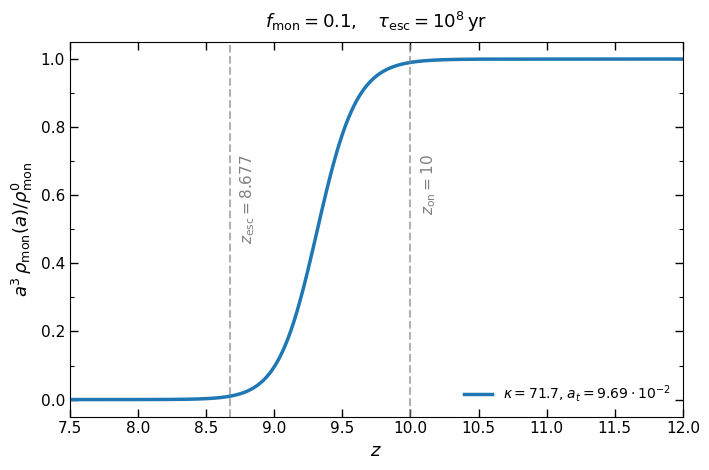

In [9]:
# =======================
# Plot settings
# =======================
f_mon = 0.1
kappa_mon_arr = [71.7201]
a_t_mon_arr = [0.096924]

tau_escape = 10**(8)
mantissa, exponent = f"{tau_escape:.1e}".split('e')

z_on = 10.0
z_escape = 8.6770

# Make plot but DON'T show yet
fig, ax = plot_evolution_comoving_dm_density(
    f_mon, kappa_mon_arr, a_t_mon_arr,
    title = rf"$f_{{\rm mon}}={f_mon}, \quad \tau_{{\rm esc}}=10^{{{int(exponent)}}}\,{{\rm yr}}$",
    xlim=(7.500, 12.000),
    return_fig=True,
    show=False,
    legend_loc="lower right",
)

# ---- vertical lines
ax.axvline(z_on, ls='--', lw=1.5, color='gray', alpha=0.6)
ax.axvline(z_escape, ls='--', lw=1.5, color='gray', alpha=0.6)

# ---- annotations (place near top of axis)
ymin, ymax = ax.get_ylim()
y_text = ymax - 0.3*(ymax - ymin)

ax.annotate(
    rf"$z_{{\rm on}}={z_on:g}$",
    xy=(z_on, y_text),
    xytext=(6, 0),
    textcoords="offset points",
    rotation=90,
    va="top",
    ha="left",
    fontsize=11,
    color="grey",
)

ax.annotate(
    rf"$z_{{\rm esc}}={z_escape:g}$",
    xy=(z_escape, y_text),
    xytext=(6, 0),
    textcoords="offset points",
    rotation=90,
    va="top",
    ha="left",
    fontsize=11,
    color="grey",
)

# Optionally: horizontal guide line (example)
# ax.axhline(1.05, color="black", ls=":", lw=1.0)
# ax.annotate(r"$y=1.05$", xy=(ax.get_xlim()[0], 1.05), xytext=(5, 3),
#             textcoords="offset points", ha="left", va="bottom", fontsize=10)

fig.tight_layout()

# Save or show
if flag_save_plot:
    fig.savefig("evolution_comoving_DM_1_annotated.pdf", dpi=200, bbox_inches="tight")

plt.show()

## Monopole density profile (small cheating)

In [10]:
# --------------------------------------------------
# Stable transition factor
# --------------------------------------------------
def monopole_profile_stable(a, kappa, a_t):
    """
    Stable evaluation of

        (1 - a^kappa) / (1 + (a/a_t)^kappa)

    for scalar or array a.

    Returns the dimensionless shape of the comoving monopole density.
    """
    a = np.asarray(a, dtype=float)

    if np.any(a <= 0):
        raise ValueError("All scale factors a must be > 0.")
    if kappa <= 0:
        raise ValueError("kappa must be > 0.")
    if a_t <= 0:
        raise ValueError("a_t must be > 0.")

    loga = np.log(a)
    logat = np.log(a_t)

    u = kappa * loga              # for a^kappa = exp(u)
    v = kappa * (loga - logat)    # for (a/a_t)^kappa = exp(v)

    # numerator: 1 - exp(u) = -expm1(u)
    num = np.empty_like(a)

    mask_u_low  = u < -50.0
    mask_u_mid  = (u >= -50.0) & (u <= 50.0)
    mask_u_high = u > 50.0

    num[mask_u_low]  = 1.0
    num[mask_u_mid]  = -np.expm1(u[mask_u_mid])
    num[mask_u_high] = -np.inf   # in practice shouldn't matter for a<=1, but safe branch

    # gate = 1 / (1 + exp(v)) done stably
    gate = np.empty_like(a)

    mask_v_low  = v < -50.0
    mask_v_mid  = (v >= -50.0) & (v <= 50.0)
    mask_v_high = v > 50.0

    gate[mask_v_low]  = 1.0
    gate[mask_v_mid]  = 1.0 / (1.0 + np.exp(v[mask_v_mid]))
    gate[mask_v_high] = np.exp(-v[mask_v_high])

    y = num * gate

    # For plotting, clip tiny negative numerical noise around zero
    y = np.maximum(y, 0.0)

    return y


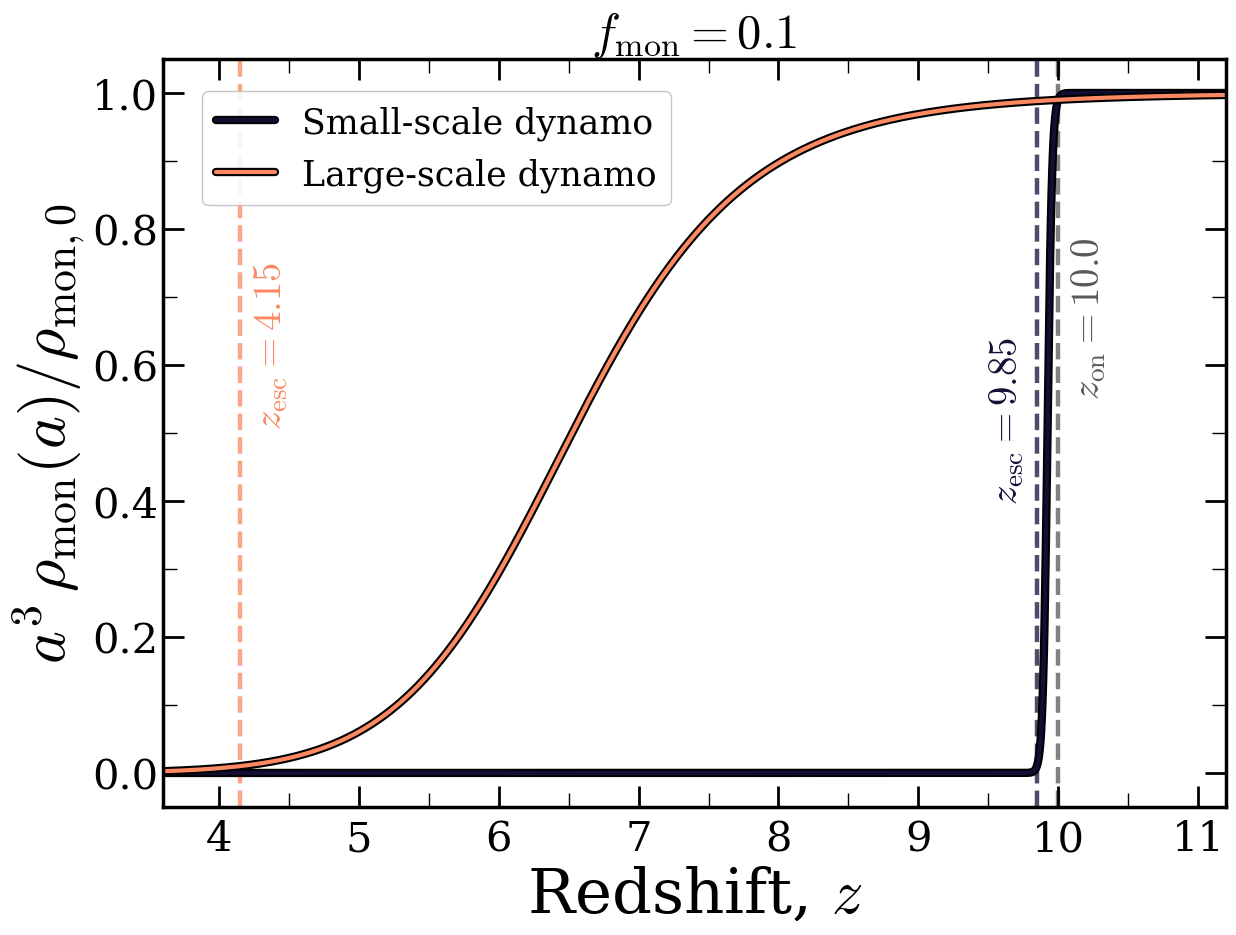

In [48]:
import matplotlib.cm as cm

# --------------------------------------------------
# Global style
# --------------------------------------------------
plt.style.use('sty.mplstyle')

flag_save_plot = True

# --------------------------------------------------
# Model parameters
# --------------------------------------------------
f_mon = 0.1

kappa = [657.4583, 12.0980]
a_t   = [0.091547, 0.132912]

# Common onset redshift
z_on = 10.0

# Endpoint of fast transition (your previous z_escape)
z_esc_broad = 4.15

# Optional: choose a meaningful endpoint for the broad case
# For example: redshift where only 1% remains unaccelerated.
# If you do not want such a marker, set this to None.
z_esc_fast = 9.8473
# Example:
# z_end_broad = 3.2

# --------------------------------------------------
# Redshift grid
# --------------------------------------------------
z = np.linspace(0.0, 20.01, 4000)
a = 1.0 / (1.0 + z)

y_broad  = monopole_profile_stable(a, kappa[0], a_t[0])
y_fast = monopole_profile_stable(a, kappa[1], a_t[1])

# --------------------------------------------------
# Colors (colorblind-safe)
# --------------------------------------------------
# cols = cm.viridis([0.25,0.5,0.75,0.9])
cols = cm.magma([0.10,0.5,0.75,0.75])


# --------------------------------------------------
# Figure
# --------------------------------------------------
fig, ax = plt.subplots(figsize=(13,10))

def PlotLines(ax):
    # ax.plot(z,y_fast,lw=5,color='gray',path_effects=[pe.Stroke(linewidth=10, foreground='k'), pe.Normal()],label=r'$\Lambda$CDM')
    ax.plot(z,y_broad,linestyle='-',color=cols[0],path_effects=[pe.Stroke(linewidth=6, foreground='k'), pe.Normal()],
            label=r'Small-scale dynamo')
    ax.plot(z,y_fast,linestyle='-',color=cols[-1],path_effects=[pe.Stroke(linewidth=6, foreground='k'), pe.Normal()],
            label=r'Large-scale dynamo')
PlotLines(ax)

# --------------------------------------------------
# Reference lines
# --------------------------------------------------
# Common onset

ax.axvline(z_on, color="0.45", ls="--", lw=3.2, alpha=0.9, zorder=0)
ax.axvline(z_esc_broad, color=cols[-1], ls="--", lw=3.2, alpha=0.75, zorder=0)
ax.axvline(z_esc_fast, color=cols[0], ls="--", lw=3.2, alpha=0.75, zorder=0)

# --------------------------------------------------
# Annotations for vertical lines
# --------------------------------------------------
box_kw = dict(
    boxstyle="round,pad=0.14",
    facecolor="white",
    edgecolor="none",
    alpha=0.78
)

ax.text(
    z_on + 0.08, 0.67,
    rf"$z_{{\rm on}} = {z_on:.1f}$",
    rotation=90,
    va="center",
    ha="left",
    # fontsize=12,
    color="0.35",
    bbox=box_kw
)

ax.text(
    z_esc_broad + 0.08, 0.63,
    rf"$z_{{\rm esc}} = {z_esc_broad:.2f}$",
    rotation=90,
    va="center",
    ha="left",
    # fontsize=12,
    color=cols[-1],
    bbox=box_kw
)

if z_esc_fast is not None:
    ax.text(
        z_esc_fast - 0.08, 0.52,
        rf"$z_{{\rm esc}} = {z_esc_fast:.2f}$",
        rotation=90,
        va="center",
        ha="right",
        # fontsize=12,
        color=cols[0],
        bbox=box_kw
    )

# --------------------------------------------------
# Axes, ticks, labels
# --------------------------------------------------
# ax.set_xlim(3.0, 12.0)
ax.set_xlim(3.6, 11.2)
ax.set_ylim(-0.05, 1.05)

ax.set_xlabel(r"Redshift, $z$")
# ax.set_ylabel(r"Comoving monopole density, $a^3\,\rho_{\rm mon}(a)/\rho_{{\rm mon},0}$")
ax.set_ylabel(r"$a^3\,\rho_{\rm mon}(a)/\rho_{{\rm mon},0}$")

ax.xaxis.set_major_locator(MultipleLocator(1.0))
ax.xaxis.set_minor_locator(AutoMinorLocator(2))
ax.yaxis.set_major_locator(MultipleLocator(0.2))
ax.yaxis.set_minor_locator(AutoMinorLocator(2))

ax.legend(
    loc="upper left",
    bbox_to_anchor=(0.02, 0.98),
    fontsize=25,
    handlelength=1.7,
    frameon=True,
    facecolor="white",
    edgecolor="0.75",
    framealpha=0.9
)

# Panel note instead of heavy title
ax.set_title(rf"$f_{{\rm mon}}={f_mon}$")


fig.tight_layout()

if flag_save_plot:
    fig.savefig("comoving_monopole_density_polished.pdf", dpi=300, bbox_inches="tight")
else:
    plt.show()